In [73]:
# If needed in a fresh environment, install the core packages first:
# !pip install torch scikit-learn matplotlib pandas numpy


In [74]:
import copy
import random

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [75]:
DATA_PATH = "combined_scaled_battery_data.csv"
WINDOW_SIZE = 10
NUM_TEST_BATTERIES = 8
NUM_VAL_BATTERIES = 8
BATCH_SIZE = 256
NUM_EPOCHS = 50
LR = 1e-3

FEATURE_COLUMNS = [
    "Discharge Time (s)",
    "Decrement 3.6-3.4V (s)",
    "Max. Voltage Dischar. (V)",
    "Min. Voltage Charg. (V)",
    "Time at 4.15V (s)",
    "Time constant current (s)",
    "Charging time (s)",
]

df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.columns)
df.head()


(17658, 10)
Index(['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)',
       'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)',
       'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)',
       'RUL', 'Is_NASA'],
      dtype='object')


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL,Is_NASA
0,1.0,0.909368,2.248505,-2.808054,-3.115605,2.005705,1.867079,2.297202,1112,0
1,2.0,5.241828,2.317965,4.102902,-3.039831,2.045062,1.871526,2.039997,1111,0
2,3.0,5.228434,2.121319,4.138897,-3.006154,2.045063,1.871526,1.965868,1110,0
3,4.0,5.220999,2.013378,4.150895,-2.997735,2.039458,1.871526,1.875424,1109,0
4,6.0,57.099956,96.943238,4.630822,-1.541204,2.022568,31.339883,44.865103,1107,0


In [76]:
def split_into_battery_segments(dataframe):
    """Split dataframe into per-battery segments by detecting RUL resets."""
    rul_values = dataframe["RUL"].values
    rul_diffs = np.diff(rul_values)
    boundary_indices = np.where(rul_diffs > 0)[0] + 1

    segment_starts = np.concatenate([[0], boundary_indices])
    segment_ends = np.concatenate([boundary_indices, [len(dataframe)]])

    segments = [
        dataframe.iloc[start:end].reset_index(drop=True)
        for start, end in zip(segment_starts, segment_ends)
    ]
    for segment_id, segment in enumerate(segments):
        segment.attrs["segment_id"] = segment_id
    return segments


battery_segments = split_into_battery_segments(df)
print("num batteries:", len(battery_segments))
print("battery lengths min/max:", min(len(s) for s in battery_segments), max(len(s) for s in battery_segments))
print("batteries by source:", pd.Series([float(s["Is_NASA"].iloc[0]) for s in battery_segments]).value_counts().sort_index().to_dict())


num batteries: 48
battery lengths min/max: 24 1067
batteries by source: {0.0: 14, 1.0: 34}


In [77]:
rng = np.random.default_rng(SEED)

# Match cnn_rul.py: reserve one CALCE/HNEI and one NASA battery for demo only.
all_calce = [s for s in battery_segments if s["Is_NASA"].iloc[0] == 0]
all_nasa = [s for s in battery_segments if s["Is_NASA"].iloc[0] == 1]
demo_calce = all_calce[rng.integers(len(all_calce))]
demo_nasa = all_nasa[rng.integers(len(all_nasa))]
demo_df = pd.concat([demo_calce, demo_nasa], ignore_index=True)
demo_df.to_csv("demo_batteries_tft.csv", index=False)

model_segments = [
    s for s in battery_segments
    if not s.equals(demo_calce) and not s.equals(demo_nasa)
]

print(
    "Demo batteries saved to demo_batteries_tft.csv "
    f"(CALCE: {len(demo_calce)} cycles, NASA: {len(demo_nasa)} cycles)"
)
print("modeling batteries:", len(model_segments))


Demo batteries saved to demo_batteries_tft.csv (CALCE: 1065 cycles, NASA: 24 cycles)
modeling batteries: 46


In [78]:
def sample_stratified_indices(segments, num_samples, rng):
    """Sample half CALCE/HNEI and half NASA segment indices without replacement."""
    calce_indices = [i for i, s in enumerate(segments) if s["Is_NASA"].iloc[0] == 0]
    nasa_indices = [i for i, s in enumerate(segments) if s["Is_NASA"].iloc[0] == 1]

    num_calce = num_samples // 2
    num_nasa = num_samples - num_calce
    if num_calce > len(calce_indices) or num_nasa > len(nasa_indices):
        raise ValueError("Not enough batteries in one source to sample the requested split.")

    return list(rng.choice(calce_indices, size=num_calce, replace=False)) + list(
        rng.choice(nasa_indices, size=num_nasa, replace=False)
    )


# Match cnn_rul.py's stratified test split, then create validation only from the remaining training pool.
test_indices = sample_stratified_indices(model_segments, NUM_TEST_BATTERIES, rng)
test_index_set = set(test_indices)
train_val_segments = [s for i, s in enumerate(model_segments) if i not in test_index_set]
test_segments = [model_segments[i] for i in test_indices]

val_local_indices = sample_stratified_indices(train_val_segments, NUM_VAL_BATTERIES, rng)
val_index_set = set(val_local_indices)
train_segments = [s for i, s in enumerate(train_val_segments) if i not in val_index_set]
val_segments = [train_val_segments[i] for i in val_local_indices]

print(f"Batteries — train: {len(train_segments)}, val: {len(val_segments)}, test: {len(test_segments)}")
for name, segments in [("train", train_segments), ("val", val_segments), ("test", test_segments)]:
    counts = pd.Series([float(s["Is_NASA"].iloc[0]) for s in segments]).value_counts().sort_index().to_dict()
    lengths = [len(s) for s in segments]
    print(f"{name:5s} source counts: {counts}, length range: {min(lengths)}-{max(lengths)}")


Batteries — train: 30, val: 8, test: 8
train source counts: {0.0: 5, 1.0: 25}, length range: 25-1067
val   source counts: {0.0: 4, 1.0: 4}, length range: 24-1065
test  source counts: {0.0: 4, 1.0: 4}, length range: 47-1067


In [79]:
train_ids = {s.attrs["segment_id"] for s in train_segments}
val_ids = {s.attrs["segment_id"] for s in val_segments}
test_ids = {s.attrs["segment_id"] for s in test_segments}
demo_ids = {demo_calce.attrs["segment_id"], demo_nasa.attrs["segment_id"]}

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)
assert train_ids.isdisjoint(demo_ids)
assert val_ids.isdisjoint(demo_ids)
assert test_ids.isdisjoint(demo_ids)

print("No battery-level leakage across train/val/test/demo splits.")
print("Train segment IDs:", sorted(train_ids))
print("Val segment IDs:", sorted(val_ids))
print("Test segment IDs:", sorted(test_ids))
print("Demo segment IDs:", sorted(demo_ids))


No battery-level leakage across train/val/test/demo splits.
Train segment IDs: [2, 3, 9, 11, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 31, 32, 33, 35, 36, 39, 41, 43, 44, 45, 47]
Val segment IDs: [0, 4, 8, 10, 26, 34, 37, 42]
Test segment IDs: [5, 6, 7, 12, 16, 30, 38, 46]
Demo segment IDs: [1, 40]


In [80]:
def build_sliding_windows(segments, window_size=WINDOW_SIZE):
    """Create raw-RUL (window, Is_NASA flag, RUL label) triples, matching cnn_rul.py."""
    windows = []
    nasa_flags = []
    labels = []

    for segment in segments:
        feature_array = segment[FEATURE_COLUMNS].values.astype(np.float32)
        rul_array = segment["RUL"].values.astype(np.float32)
        is_nasa_flag = float(segment["Is_NASA"].iloc[0])

        # cnn_rul.py uses range(len(segment) - window_size), not +1.
        for i in range(len(segment) - window_size):
            windows.append(feature_array[i : i + window_size])
            nasa_flags.append(is_nasa_flag)
            labels.append(rul_array[i + window_size - 1])

    return (
        np.asarray(windows, dtype=np.float32),
        np.asarray(nasa_flags, dtype=np.float32),
        np.asarray(labels, dtype=np.float32),
    )


X_train, nasa_train, y_train = build_sliding_windows(train_segments)
X_val, nasa_val, y_val = build_sliding_windows(val_segments)
X_test, nasa_test, y_test = build_sliding_windows(test_segments)

print("Train windows:", X_train.shape, nasa_train.shape, y_train.shape)
print("Val windows:  ", X_val.shape, nasa_val.shape, y_val.shape)
print("Test windows: ", X_test.shape, nasa_test.shape, y_test.shape)
print("Feature count:", len(FEATURE_COLUMNS))

for name, flags, labels in [("train", nasa_train, y_train), ("val", nasa_val, y_val), ("test", nasa_test, y_test)]:
    print(f"\n{name} windows by source:", pd.Series(flags).value_counts().sort_index().to_dict())
    for flag, source_name in [(0.0, "HNEI / CALCE"), (1.0, "NASA")]:
        mask = flags == flag
        if mask.any():
            print(
                f"  {source_name:11s} n={mask.sum():5d} "
                f"mean={labels[mask].mean():8.2f} std={labels[mask].std():8.2f} "
                f"min={labels[mask].min():6.1f} max={labels[mask].max():6.1f}"
            )


Train windows: (6972, 10, 7) (6972,) (6972,)
Val windows:   (4577, 10, 7) (4577,) (4577,)
Test windows:  (4560, 10, 7) (4560,) (4560,)
Feature count: 7

train windows by source: {0.0: 5252, 1.0: 1720}
  HNEI / CALCE n= 5252 mean=  548.39 std=  318.23 min=   2.0 max=1098.0
  NASA        n= 1720 mean=   56.73 std=   46.45 min=   1.0 max= 187.0

val windows by source: {0.0: 4214, 1.0: 363}
  HNEI / CALCE n= 4214 mean=  553.07 std=  320.75 min=   2.0 max=1121.0
  NASA        n=  363 mean=   68.42 std=   50.79 min=   1.0 max= 187.0

test windows by source: {0.0: 4213, 1.0: 347}
  HNEI / CALCE n= 4213 mean=  546.79 std=  317.58 min=   2.0 max=1101.0
  NASA        n=  347 mean=   56.01 std=   41.53 min=   1.0 max= 158.0


In [81]:
class BatteryWindowDataset(Dataset):
    def __init__(self, windows, nasa_flags, labels):
        # Conv1d expects (batch, channels, length), so transpose (N, T, C) -> (N, C, T).
        self.temporal = torch.tensor(windows, dtype=torch.float32).permute(0, 2, 1)
        self.static = torch.tensor(nasa_flags, dtype=torch.float32).unsqueeze(1)
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.temporal[idx], self.static[idx], self.labels[idx]


train_loader = DataLoader(
    BatteryWindowDataset(X_train, nasa_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    BatteryWindowDataset(X_val, nasa_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    BatteryWindowDataset(X_test, nasa_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


In [82]:
# The original dataframe is no longer used after battery-level splitting.
# Keeping the split objects explicit helps avoid accidental row-level leakage.
print("Demo rows:", len(demo_df))
print("Train/val/test rows:", sum(len(s) for s in train_segments), sum(len(s) for s in val_segments), sum(len(s) for s in test_segments))


Demo rows: 1089
Train/val/test rows: 7272 4657 4640


In [83]:
print("Data loaders:")
print("  train batches:", len(train_loader))
print("  val batches:  ", len(val_loader))
print("  test batches: ", len(test_loader))


Data loaders:
  train batches: 28
  val batches:   18
  test batches:  18


In [84]:
print("Using raw RUL targets, no target normalization, and no source-balanced sampler.")
print("This matches cnn_rul.py's target protocol while keeping test data held out from training/validation.")


Using raw RUL targets, no target normalization, and no source-balanced sampler.
This matches cnn_rul.py's target protocol while keeping test data held out from training/validation.


In [85]:
# Dataset and dataloaders were constructed above after the leakage-safe split.


In [86]:
from pathlib import Path


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=kernel_size // 2,
            ),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class GatedResidualNetwork(nn.Module):
    """Small GRN used in TFT-style temporal fusion."""

    def __init__(self, input_size, hidden_size, output_size=None, dropout=0.1):
        super().__init__()
        output_size = output_size or input_size
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)
        self.skip = nn.Identity() if input_size == output_size else nn.Linear(input_size, output_size)
        self.gate = nn.Linear(output_size, output_size)
        self.norm = nn.LayerNorm(output_size)

    def forward(self, x):
        residual = self.skip(x)
        x = self.fc2(self.dropout(self.elu(self.fc1(x))))
        gated = torch.sigmoid(self.gate(x)) * x
        return self.norm(residual + gated)


class GateAddNorm(nn.Module):
    """TFT-style gated skip connection followed by layer normalization."""

    def __init__(self, hidden_size):
        super().__init__()
        self.gate = nn.Linear(hidden_size, hidden_size)
        self.norm = nn.LayerNorm(hidden_size)

    def forward(self, x, residual):
        gated = torch.sigmoid(self.gate(x)) * x
        return self.norm(residual + gated)


class TemporalFusionBlock(nn.Module):
    """Compact TFT-style temporal encoder for fixed sliding windows."""

    def __init__(self, hidden_size=64, num_heads=4, dropout=0.1):
        super().__init__()
        self.input_grn = GatedResidualNetwork(hidden_size, hidden_size, dropout=dropout)
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.post_lstm_gate_norm = GateAddNorm(hidden_size)
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.post_attention_gate_norm = GateAddNorm(hidden_size)
        self.positionwise_grn = GatedResidualNetwork(hidden_size, hidden_size, dropout=dropout)

    def forward(self, x):
        x = self.input_grn(x)
        lstm_out, _ = self.lstm(x)
        lstm_out = self.post_lstm_gate_norm(lstm_out, x)
        attention_out, _ = self.attention(lstm_out, lstm_out, lstm_out, need_weights=False)
        fused = self.post_attention_gate_norm(attention_out, lstm_out)
        fused = self.positionwise_grn(fused)
        return fused[:, -1, :]


class DualBranchTFTNet(nn.Module):
    """Dual-branch TFT-style RUL regressor.

    Branch A: Conv1D layers extract local degradation patterns from the
    7-feature sliding window, then a compact TFT-style temporal fusion block
    produces a 64-dimensional temporal representation.
    Branch B: Is_NASA, where 0=CALCE and 1=NASA, passes through Linear(1 -> 8).
    Head: concatenate to 72 features, then Linear(72 -> 64 -> 1).
    """

    def __init__(self, num_features, hidden_size=64, static_size=8, num_heads=4, dropout=0.1):
        super().__init__()
        self.conv_feature_extractor = nn.Sequential(
            ConvBlock(num_features, hidden_size),
            ConvBlock(hidden_size, hidden_size),
            ConvBlock(hidden_size, hidden_size),
        )
        self.temporal_fusion = TemporalFusionBlock(
            hidden_size=hidden_size,
            num_heads=num_heads,
            dropout=dropout,
        )

        self.static_branch = nn.Sequential(
            nn.Linear(1, static_size),
            nn.ReLU(),
        )

        self.regression_head = nn.Sequential(
            nn.Linear(hidden_size + static_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, temporal_window, is_nasa):
        conv_features = self.conv_feature_extractor(temporal_window)
        conv_features = conv_features.transpose(1, 2)
        temporal_features = self.temporal_fusion(conv_features)
        static_features = self.static_branch(is_nasa)
        combined = torch.cat([temporal_features, static_features], dim=1)
        return self.regression_head(combined)


def train_one_epoch(model, loader, optimizer, device, nasa_weight):
    model.train()
    total_loss = 0.0
    total_weighted_loss = 0.0

    for temporal_window, is_nasa, target in loader:
        temporal_window = temporal_window.to(device)
        is_nasa = is_nasa.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        predictions = model(temporal_window, is_nasa)
        sample_losses = (predictions - target).pow(2)
        sample_weights = torch.where(
            is_nasa == 1.0,
            torch.full_like(is_nasa, float(nasa_weight)),
            torch.ones_like(is_nasa),
        )
        loss = (sample_losses * sample_weights).mean()
        loss.backward()
        optimizer.step()

        batch_size = len(target)
        total_loss += sample_losses.mean().item() * batch_size
        total_weighted_loss += loss.item() * batch_size

    return {
        "train_loss": total_loss / len(loader.dataset),
        "train_weighted_loss": total_weighted_loss / len(loader.dataset),
    }


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    all_sources = []

    with torch.no_grad():
        for temporal_window, is_nasa, target in loader:
            temporal_window = temporal_window.to(device)
            is_nasa_device = is_nasa.to(device)
            target = target.to(device)

            predictions = model(temporal_window, is_nasa_device)
            total_loss += (predictions - target).pow(2).mean().item() * len(target)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(target.cpu().numpy())
            all_sources.append(is_nasa.numpy())

    avg_loss = total_loss / len(loader.dataset)
    predictions = np.concatenate(all_predictions).ravel()
    targets = np.concatenate(all_targets).ravel()
    sources = np.concatenate(all_sources).ravel()
    return avg_loss, predictions, targets, sources


def regression_metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def compute_source_metrics(y_true, y_pred, sources):
    metrics = {}
    metrics.update({f"overall_{k}": v for k, v in regression_metrics(y_true, y_pred).items()})

    for source_value, prefix in [(0.0, "hnei"), (1.0, "nasa")]:
        mask = sources == source_value
        source_metrics = regression_metrics(y_true[mask], y_pred[mask])
        metrics[f"{prefix}_n"] = int(mask.sum())
        for key, value in source_metrics.items():
            metrics[f"{prefix}_{key}"] = value

    return metrics


def weight_label(nasa_weight):
    return str(nasa_weight).replace(".", "p")


def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

PATIENCE = 8
NASA_WEIGHT_SWEEP = [1.0, 1.5, 2.0, 3.0, 4.0]
SWEEP_OUTPUT_DIR = Path("tft_nasa_weight_sweep")
SWEEP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

probe_model = DualBranchTFTNet(num_features=len(FEATURE_COLUMNS)).to(device)
num_params = sum(p.numel() for p in probe_model.parameters() if p.requires_grad)
print(probe_model)
print(f"Using device: {device}")
print(f"Trainable parameters: {num_params:,}")
del probe_model


DualBranchTFTNet(
  (conv_feature_extractor): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv1d(7, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
  )
  (temporal_fusion): TemporalFusionBlock(
    (input_grn): GatedResidualNetwork(
      (fc1): Linear(in_features=64, out_features=64, bias=True)
      (elu): ELU(alpha=1.0)
      (fc2): Linear(in_fe

In [87]:
sweep_results = []
sweep_histories = {}
best_models = {}

for nasa_weight in NASA_WEIGHT_SWEEP:
    reset_seed(SEED)
    run_label = f"nasa_weight_{weight_label(nasa_weight)}"
    run_dir = SWEEP_OUTPUT_DIR / run_label
    checkpoint_dir = run_dir / "checkpoints"
    metrics_dir = run_dir / "metrics"
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    metrics_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n=== Training with NASA weight = {nasa_weight} ===")
    model = DualBranchTFTNet(num_features=len(FEATURE_COLUMNS)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, device, nasa_weight)
        val_loss, _, _, _ = evaluate(model, val_loader, device)
        scheduler.step()

        history.append({
            "epoch": epoch,
            "nasa_weight": nasa_weight,
            "train_loss": train_metrics["train_loss"],
            "train_weighted_loss": train_metrics["train_weighted_loss"],
            "val_loss": val_loss,
            "learning_rate": scheduler.get_last_lr()[0],
        })

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"weight={nasa_weight:g} epoch {epoch:02d}/{NUM_EPOCHS} "
            f"train_loss={train_metrics['train_loss']:.4f} "
            f"weighted_loss={train_metrics['train_weighted_loss']:.4f} "
            f"val_loss={val_loss:.4f}"
        )

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, preds, acts, test_sources = evaluate(model, test_loader, device)
    row = {
        "nasa_weight": nasa_weight,
        "hnei_weight": 1.0,
        "best_epoch": best_epoch,
        "best_val_loss": float(best_val_loss),
        "test_mse": float(test_loss),
        "output_dir": str(run_dir),
        "checkpoint_path": str(checkpoint_dir / "best_model.pt"),
    }
    row.update(compute_source_metrics(acts, preds, test_sources))
    sweep_results.append(row)

    history_df = pd.DataFrame(history)
    metrics_df = pd.DataFrame([row])
    predictions_df = pd.DataFrame({
        "true_rul": acts,
        "predicted_rul": preds,
        "Is_NASA": test_sources,
    })

    history_df.to_csv(metrics_dir / "history.csv", index=False)
    metrics_df.to_csv(metrics_dir / "metrics.csv", index=False)
    predictions_df.to_csv(metrics_dir / "test_predictions.csv", index=False)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "nasa_weight": nasa_weight,
            "hnei_weight": 1.0,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "metrics": row,
        },
        checkpoint_dir / "best_model.pt",
    )

    sweep_histories[nasa_weight] = history_df
    best_models[nasa_weight] = copy.deepcopy(model.state_dict())

    print(
        f"weight={nasa_weight:g} overall RMSE={row['overall_rmse']:.4f} "
        f"HNEI R2={row['hnei_r2']:.4f} NASA R2={row['nasa_r2']:.4f}"
    )

results_df = pd.DataFrame(sweep_results)
results_csv_path = SWEEP_OUTPUT_DIR / "nasa_weight_sweep_results.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"\nSaved combined results to {results_csv_path}")
results_df



=== Training with NASA weight = 1.0 ===
weight=1 epoch 01/50 train_loss=301523.2830 weighted_loss=301523.2830 val_loss=369748.9074
weight=1 epoch 02/50 train_loss=292992.0233 weighted_loss=292992.0233 val_loss=354155.7167
weight=1 epoch 03/50 train_loss=275290.9739 weighted_loss=275290.9739 val_loss=325406.7007
weight=1 epoch 04/50 train_loss=246921.6869 weighted_loss=246921.6869 val_loss=283500.6278
weight=1 epoch 05/50 train_loss=208990.2907 weighted_loss=208990.2907 val_loss=230770.9366
weight=1 epoch 06/50 train_loss=165274.8900 weighted_loss=165274.8900 val_loss=174428.6070
weight=1 epoch 07/50 train_loss=123123.1901 weighted_loss=123123.1901 val_loss=125620.8459
weight=1 epoch 08/50 train_loss=81458.3655 weighted_loss=81458.3655 val_loss=82841.2331
weight=1 epoch 09/50 train_loss=50911.6537 weighted_loss=50911.6537 val_loss=50354.4347
weight=1 epoch 10/50 train_loss=29887.2615 weighted_loss=29887.2615 val_loss=31686.4061
weight=1 epoch 11/50 train_loss=17514.4566 weighted_loss=1

,nasa_weight,hnei_weight,best_epoch,best_val_loss,test_mse,output_dir,checkpoint_path,overall_mae,overall_rmse,overall_r2,hnei_n,hnei_mae,hnei_rmse,hnei_r2,nasa_n,nasa_mae,nasa_rmse,nasa_r2
0,1.0,1.0,28,3898.581730,15651.466075,tft_nasa_weight_sweep/nasa_weight_1p0,tft_nasa_weight_sweep/nasa_weight_1p0/checkpoi...,81.358704,125.105822,0.858029,4213,86.777901,130.025013,0.832367,347,15.563218,20.341444,0.760120
1,1.5,1.0,31,4031.882482,11479.579761,tft_nasa_weight_sweep/nasa_weight_1p5,tft_nasa_weight_sweep/nasa_weight_1p5/checkpoi...,76.496124,107.142807,0.895872,4213,81.451355,111.324685,0.877118,347,16.333618,19.679893,0.775469
2,2.0,1.0,28,3797.957586,6050.205107,tft_nasa_weight_sweep/nasa_weight_2p0,tft_nasa_weight_sweep/nasa_weight_2p0/checkpoi...,58.890385,77.783061,0.945120,4213,62.416603,80.724751,0.935387,347,16.077812,19.723078,0.774482
3,3.0,1.0,22,4245.316846,10601.390675,tft_nasa_weight_sweep/nasa_weight_3p0,tft_nasa_weight_sweep/nasa_weight_3p0/checkpoi...,72.679176,102.963059,0.903837,4213,77.247993,106.953905,0.886577,347,17.208187,20.739551,0.750638
4,4.0,1.0,31,4425.048021,14243.646276,tft_nasa_weight_sweep/nasa_weight_4p0,tft_nasa_weight_sweep/nasa_weight_4p0/checkpoi...,80.146210,119.346745,0.870799,4213,85.575020,124.057009,0.847402,347,14.233944,17.994280,0.812284


In [88]:
display_columns = [
    "nasa_weight",
    "best_epoch",
    "best_val_loss",
    "overall_mae",
    "overall_rmse",
    "overall_r2",
    "hnei_mae",
    "hnei_rmse",
    "hnei_r2",
    "nasa_mae",
    "nasa_rmse",
    "nasa_r2",
]

print(results_df[display_columns].to_string(index=False))


 nasa_weight  best_epoch  best_val_loss  overall_mae  overall_rmse  overall_r2  hnei_mae  hnei_rmse  hnei_r2  nasa_mae  nasa_rmse  nasa_r2
         1.0          28    3898.581730    81.358704    125.105822    0.858029 86.777901 130.025013 0.832367 15.563218  20.341444 0.760120
         1.5          31    4031.882482    76.496124    107.142807    0.895872 81.451355 111.324685 0.877118 16.333618  19.679893 0.775469
         2.0          28    3797.957586    58.890385     77.783061    0.945120 62.416603  80.724751 0.935387 16.077812  19.723078 0.774482
         3.0          22    4245.316846    72.679176    102.963059    0.903837 77.247993 106.953905 0.886577 17.208187  20.739551 0.750638
         4.0          31    4425.048021    80.146210    119.346745    0.870799 85.575020 124.057009 0.847402 14.233944  17.994280 0.812284


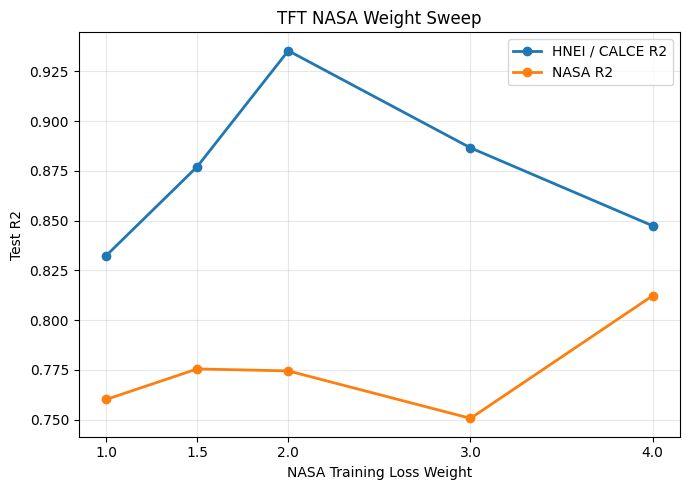

Saved summary plot to tft_nasa_weight_sweep/hnei_nasa_r2_vs_nasa_weight.png


In [89]:
plt.figure(figsize=(7, 5))
plt.plot(results_df["nasa_weight"], results_df["hnei_r2"], marker="o", linewidth=2, label="HNEI / CALCE R2")
plt.plot(results_df["nasa_weight"], results_df["nasa_r2"], marker="o", linewidth=2, label="NASA R2")
plt.xlabel("NASA Training Loss Weight")
plt.ylabel("Test R2")
plt.title("TFT NASA Weight Sweep")
plt.xticks(results_df["nasa_weight"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
summary_plot_path = SWEEP_OUTPUT_DIR / "hnei_nasa_r2_vs_nasa_weight.png"
plt.savefig(summary_plot_path, dpi=150)
plt.show()
print(f"Saved summary plot to {summary_plot_path}")


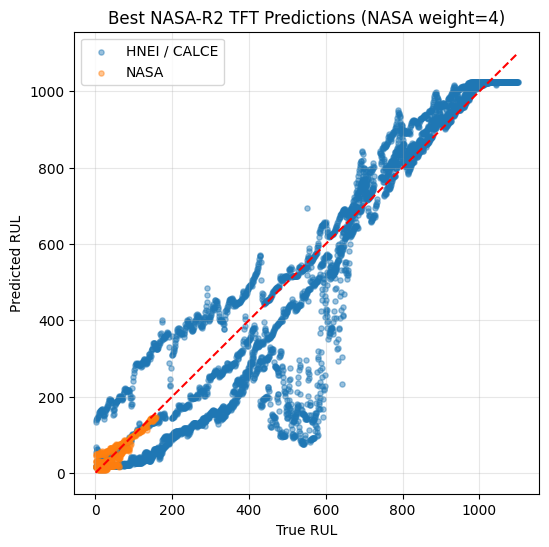

In [90]:
best_weight = results_df.sort_values("nasa_r2", ascending=False).iloc[0]["nasa_weight"]
best_predictions_path = Path(results_df.loc[results_df["nasa_weight"] == best_weight, "output_dir"].iloc[0]) / "metrics" / "test_predictions.csv"
best_predictions_df = pd.read_csv(best_predictions_path)

plt.figure(figsize=(6, 6))
hnei_mask = best_predictions_df["Is_NASA"].to_numpy() == 0
nasa_mask = best_predictions_df["Is_NASA"].to_numpy() == 1
acts = best_predictions_df["true_rul"].to_numpy()
preds = best_predictions_df["predicted_rul"].to_numpy()

plt.scatter(acts[hnei_mask], preds[hnei_mask], alpha=0.45, s=14, label="HNEI / CALCE", color="tab:blue")
plt.scatter(acts[nasa_mask], preds[nasa_mask], alpha=0.45, s=14, label="NASA", color="tab:orange")
min_rul = min(acts.min(), preds.min())
max_rul = max(acts.max(), preds.max())
plt.plot([min_rul, max_rul], [min_rul, max_rul], linestyle="--", color="red")
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title(f"Best NASA-R2 TFT Predictions (NASA weight={best_weight:g})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


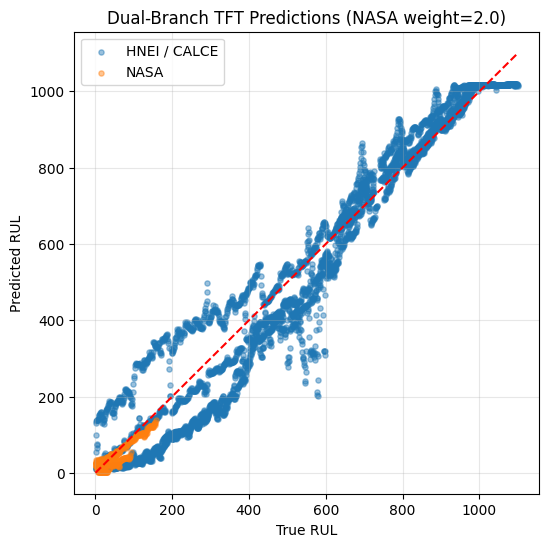

In [91]:
nasa_weight_to_plot = 2.0
prediction_path = (
    SWEEP_OUTPUT_DIR
    / f"nasa_weight_{weight_label(nasa_weight_to_plot)}"
    / "metrics"
    / "test_predictions.csv"
)

if not prediction_path.exists():
    raise FileNotFoundError(
        f"Missing {prediction_path}. Run the NASA weight sweep cell first."
    )

weight_2_predictions_df = pd.read_csv(prediction_path)
acts = weight_2_predictions_df["true_rul"].to_numpy()
preds = weight_2_predictions_df["predicted_rul"].to_numpy()
sources = weight_2_predictions_df["Is_NASA"].to_numpy()

hnei_mask = sources == 0
nasa_mask = sources == 1

plt.figure(figsize=(6, 6))
plt.scatter(acts[hnei_mask], preds[hnei_mask], alpha=0.45, s=14, label="HNEI / CALCE", color="tab:blue")
plt.scatter(acts[nasa_mask], preds[nasa_mask], alpha=0.45, s=14, label="NASA", color="tab:orange")
min_rul = min(acts.min(), preds.min())
max_rul = max(acts.max(), preds.max())
plt.plot([min_rul, max_rul], [min_rul, max_rul], linestyle="--", color="red")
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Dual-Branch TFT Predictions (NASA weight=2.0)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [92]:
nasa_weight_checkpoint = 2.0
source_checkpoint_path = (
    SWEEP_OUTPUT_DIR
    / f"nasa_weight_{weight_label(nasa_weight_checkpoint)}"
    / "checkpoints"
    / "best_model.pt"
)
standalone_checkpoint_path = SWEEP_OUTPUT_DIR / "tft_nasa_weight_2p0_checkpoint.pt"

if not source_checkpoint_path.exists():
    raise FileNotFoundError(
        f"Missing {source_checkpoint_path}. Run the NASA weight sweep cell first."
    )

checkpoint = torch.load(source_checkpoint_path, map_location="cpu")
torch.save(checkpoint, standalone_checkpoint_path)
print(f"Saved NASA weight 2.0 checkpoint to {standalone_checkpoint_path}")


Saved NASA weight 2.0 checkpoint to tft_nasa_weight_sweep/tft_nasa_weight_2p0_checkpoint.pt
